In [16]:
#@title Instalacion de librerías GEKKO, Matplotlib, Nummpy y Pandas
!pip install numpy
!pip install gekko
!pip install matplotlib
!pip install pandas


# Optimización de la producción de proteínas recombinantes mediante Pichia pastoris en  un cultivo por lote alimentado a partir de un modelo matemático.

### Estudio de Caso 1.  A partir de los datos publicados en el artículo de Barrigon et al (2015)

Revisitado


<>:132: SyntaxWarning: invalid escape sequence '\,'
<>:201: SyntaxWarning: invalid escape sequence '\,'
<>:219: SyntaxWarning: invalid escape sequence '\,'
<>:132: SyntaxWarning: invalid escape sequence '\,'
<>:201: SyntaxWarning: invalid escape sequence '\,'
<>:219: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_6373/1059506452.py:132: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_ylabel('Feed rate ($L\,h^{-1}$)', color=color)
/tmp/ipykernel_6373/1059506452.py:201: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_ylabel('Biomass ($g\,L^{-1}$)', color=color)
/tmp/ipykernel_6373/1059506452.py:219: SyntaxWarning: invalid escape sequence '\,'
  ax2.set_ylabel('Methanol ($g\,L^{-1}$)', color=color)


 ----------------------------------------------------------------
 APMonitor, Version 1.0.3
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 --------- APM Model Size ------------
 Each time step contains
   Objects      :            0
   Constants    :            0
   Variables    :            7
   Intermediates:            0
   Connections  :            1
   Equations    :            5
   Residuals    :            5
 
 Number of state variables:           1102
 Number of total equations: -         1050
 Number of slack variables: -            0
 ---------------------------------------
 Degrees of freedom       :             52
 
 solver            3  not supported
 using default solver: APOPT
 ----------------------------------------------
 Dynamic Control with APOPT Solver
 ----------------------------------------------
 
 Iter    Objective  Convergence
    0 -1.10119E+04  1.04651E-01
    1 -1.12079E+04  2.75802E-03
    2 -6.60077E+

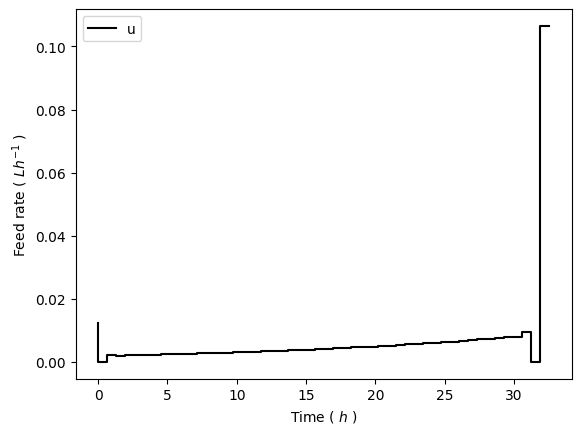

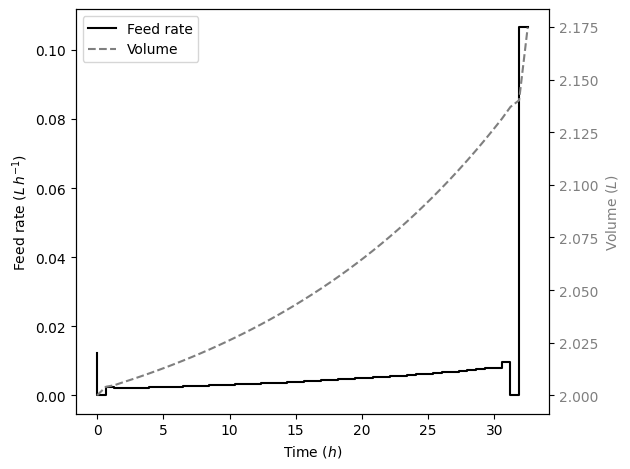

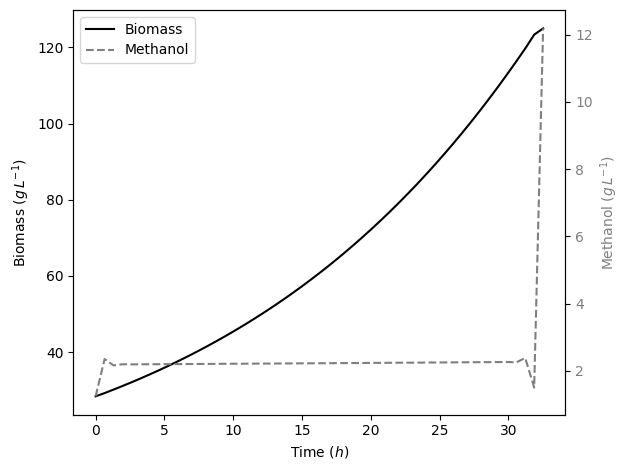

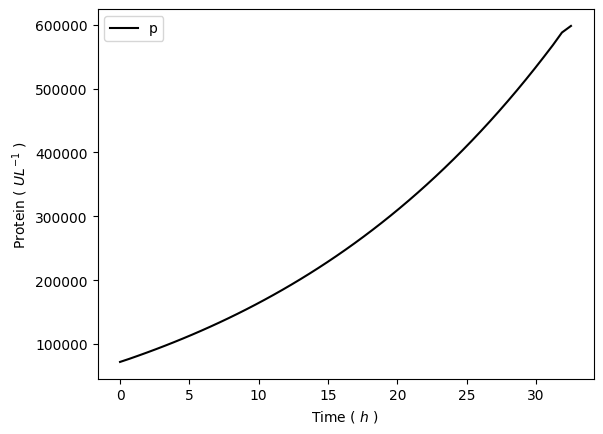

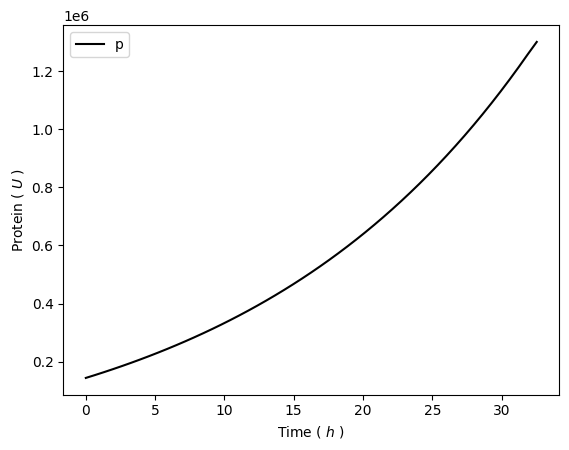

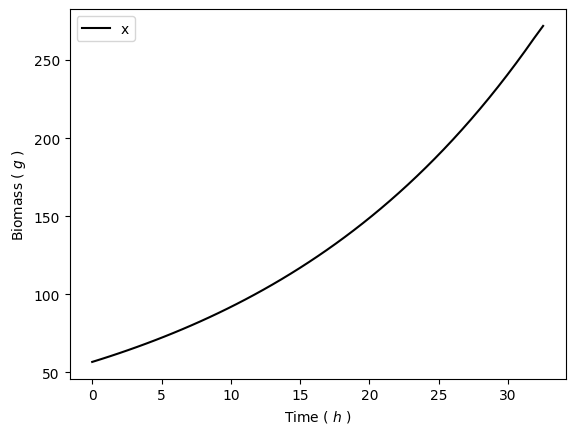

[0.012260894376, 0.00012617626017, 0.0022744257482, 0.0019801542057, 0.0021053011268, 0.0021618337442, 0.0022328086231, 0.0023012983631, 0.0023779156458, 0.0024516832839, 0.0025302336091, 0.0026101721525, 0.0026930010413, 0.0027794560847, 0.0028671345664, 0.0029587103349, 0.0030524071279, 0.0031497205213, 0.0032501292514, 0.0033529313066, 0.003460119783, 0.0035701274424, 0.0036826733711, 0.0038012948085, 0.0039214662138, 0.0040462853061, 0.0041750976922, 0.0043074684928, 0.0044450433572, 0.0045858370206, 0.0047323664177, 0.0048824628417, 0.0050372290299, 0.0052001404442, 0.0053616210681, 0.0055333618025, 0.005710543841, 0.0058916255491, 0.0060785101564, 0.0062728133793, 0.0064711266224, 0.0066774483601, 0.0068898022637, 0.0071088888072, 0.0073353636896, 0.0075667200864, 0.0078243255607, 0.0079113600929, 0.0095388479893, 0.0, 0.1065160129]
[ 0.          0.65062987  1.30125975  1.95188962  2.6025195   3.25314937
  3.90377925  4.55440912  5.205039    5.85566887  6.50629875  7.15692862
  7

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gekko import GEKKO

m=GEKKO()
nt=51 ##fijo
#nt=101
#nt=201
m.time=np.linspace(0,1,nt)

#Variables
x=m.Var(value=28.385,lb=0,ub=125) # densidad de biomasa
s=m.Var(value=1.2439,lb=0,ub=20) #densidad de Metanol
r=m.Var(value=72000,lb=0) #densidad de proteína
v=m.Var(value=2,lb=0,ub=12) #volumen#mu=m.Var(value=0,lb=0) #mu
#mup=m.Var(value=0,lb=0) #mup
##c=m.Var(value=1,lb=0) #oxígeno disuelto

p=np.zeros(nt) #vector nulo de longitud nt
p[-1]=1.0 # reemplazamos la última coodirnada de p por 1
final=m.Param(value=p)
#FV
tf=m.FV(value=1.0,lb=20,ub=80)
tf.STATUS=1
#Parametros
u=m.MV(lb=0,ub=1)
u.STATUS=1
u.DCOST=0
m.free_initial(u)


#@markdown ####*Parametros básicos a ajustar:*
#Velocidad específica máxima de crecimiento
MuM = 0.069
#Constante de sustrato
KM = 0.4
#Constante de inhibición (g/L)
KI = 8.85
#Rendimiento sustrato (g/g)
YM = 4.21
#Concentración de Sustrato que ingresa (g/L) - 792 g/L es metanol puro
MF = 792
# Coeficiente de mantención
Mm = 0.0142
# Constante beta en el modelo de L-Piret
bet = 39.3
# Constante alfa en el modelo de L-Piret
alf = 4567


##kla= 360  # Barrigon et al. 2012
##C= 0.00066  # Barrigon et al. 2012
#C= 0.008  # Diego
##YO2= 0.169  # Barrigon et al. 2012

#DEfinición qp a tramos

#qp = m.if2(s-1.9, bet,bet+alf*(MuM*s/(KM+s+(s**2)/KI)))

#Definición suavizada

mu = MuM*s/(KM+s+s**2/KI)

k = 10
H = 0.5*(1 + m.tanh(k*(s-1.9)))

qp = bet + H*alf*mu

#Ecuaciones
m.Equation(x.dt()==((MuM*s/(KM+s+(s**2)/KI)*x-(u*x)/v)*tf))#((MuM*s/(KM+s+(s**2)/KI))*x-(u*x)/v)*tf) #biomasa
m.Equation(s.dt()==(u*(MF-s)/v-(Mm+(1/YM)*(MuM*s/(KM+s+(s**2)/KI)))*x)*tf) #sustrato
m.Equation(r.dt()==(x*qp-(u*r)/v)*tf) #proteina
##m.Equation(c.dt()==( -c*u/v + kla*(C-c)-(1/YO2)*(MuM*s/(KM+s+(s**2)/KI))*x )*tf) #oxigeno disuelto
m.Equation(v.dt()==u*tf)



#Función Objetivo
m.Obj(-((r*v)*final)/tf)
#Solver
m.options.IMODE=6   # Control Optimo Método Simultaneo
m.options.NODES=3   # Nodos de colocación
m.options.MV_TYPE=1
m.options.MAX_ITER=300
m.options.SOLVER=3

m.solve(disp=True)
print('Tiempo final:'+str(tf.value[0]))
print('Densidad de Proteina final:'+str((r.value[-1])))
print('Proteina final:'+str((r.value[-1])*v.value[-1]))
print('Productividad de proteina:'+str(r.value[-1]*v.value[-1]/tf.value[0]))
print('Densidad de Biomasa final:'+str((x.value[-1])))
print('Biomasa final:'+str((x.value[-1])*v.value[-1]))


#Transformación de unidades

X=np.multiply(v,x)

S=np.multiply(v,s)

R=np.multiply(v,r)

#DX=np.multiply(X,mu)

#DR=np.multiply(X,mup)

tm=m.time*tf.value[0]


#Construcción de graficos

plt.step(tm, u, where='pre', label='u',color='k')
plt.legend(loc='best')
plt.xlabel('Time ( $h$ )')
plt.ylabel('Feed rate ( $L h^{-1}$ )')
plt.savefig('FigA.png', format='png')
plt.show()

#########################################

fig, ax1 = plt.subplots()

# ============================================================
# Eje izquierdo: Feed rate
# ============================================================

color = 'k'

ax1.set_xlabel('Time ($h$)')
ax1.set_ylabel('Feed rate ($L\,h^{-1}$)', color=color)

line1 = ax1.step(
    tm, u,
    color=color,
    label='Feed rate'
)

ax1.tick_params(axis='y', labelcolor=color)

# ============================================================
# Eje derecho: Volume
# ============================================================

ax2 = ax1.twinx()

color = 'tab:gray'

ax2.set_ylabel('Volume ($L$)', color=color)

line2, = ax2.plot(
    tm, v,
    '--',
    color=color,
    label='Volume'
)

ax2.tick_params(axis='y', labelcolor=color)

# ============================================================
# Leyenda combinada
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left',
    frameon=True
)

# ============================================================
# Ajuste y guardado
# ============================================================

fig.tight_layout()

plt.savefig(
    'FigB.png',
    format='png',
    dpi=300
)

plt.show()

##########################################################


fig, ax1 = plt.subplots()

# ============================================================
# Eje izquierdo: Biomass
# ============================================================

color = 'k'

ax1.set_xlabel('Time ($h$)')
ax1.set_ylabel('Biomass ($g\,L^{-1}$)', color=color)

ax1.plot(
    tm, x,
    color=color,
    label='Biomass'
)

ax1.tick_params(axis='y', labelcolor=color)

# ============================================================
# Eje derecho: Methanol
# ============================================================

ax2 = ax1.twinx()

color = 'tab:gray'

ax2.set_ylabel('Methanol ($g\,L^{-1}$)', color=color)

ax2.plot(
    tm, s,
    '--',
    color=color,
    label='Methanol'
)

ax2.tick_params(axis='y', labelcolor=color)

# ============================================================
# Leyenda combinada
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left',
    frameon=True
)

# ============================================================
# Ajuste y guardado
# ============================================================

fig.tight_layout()

plt.savefig(
    'FigC.png',
    format='png',
    dpi=300
)

plt.show()

##########################################

plt.plot(tm, r, label='p',color='k')
plt.legend(loc='best')
plt.xlabel('Time ( $h$ )')
plt.ylabel('Protein ( $U L^{-1}$ )')
plt.savefig('FigD.png', format='png')
plt.show()


plt.plot(tm, R, label='p',color='k')
plt.legend(loc='best')
plt.xlabel('Time ( $h$ )')
plt.ylabel('Protein ( $U $ )')
plt.savefig('FigE.png', format='png')
plt.show()


plt.plot(tm, X, label='x',color='k')
plt.legend(loc='best')
plt.xlabel('Time ( $h$ )')
plt.ylabel('Biomass ( $g $ )')
plt.savefig('FigF.png', format='png')
plt.show()

#plt.plot(tm, c, label='x',color='k')
#plt.legend(loc='best')
#plt.xlabel('Time ( $h$ )')
#plt.ylabel('Dissolved oxygen ( $g  L^{-1} $ )')
#plt.savefig('FigG.eps', format='eps')
#plt.show()

print(u.value)

print(tm)


# Comparación de los datos directamente

In [18]:
import numpy as np
import pandas as pd

# ============================================================
# Cantidades totales
# ============================================================

X = np.array(v.value) * np.array(x.value)
R = np.array(v.value) * np.array(r.value)

# ============================================================
# Incrementos respecto del estado inicial
# ============================================================

Delta_XV = X - X[0]
Delta_RV = R - R[0]

# ============================================================
# Construcción de la tabla de resultados
# ============================================================

tabla = pd.DataFrame({

    'Time': tm,

    # Concentraciones
    'Biomass_density': x.value,
    'Substrate': s.value,
    'Protein_density': r.value,

    # Cantidades totales
    'Total_biomass': X,
    'Total_protein': R,

    # Incrementos respecto del valor inicial
    'Delta_XV': Delta_XV,
    'Delta_RV': Delta_RV,

    # Variables del proceso
    'Feed_rate': u.value,
    'Volume': v.value

})

tabla

/tmp/ipykernel_6373/1080573163.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  X = np.array(v.value) * np.array(x.value)
/tmp/ipykernel_6373/1080573163.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  R = np.array(v.value) * np.array(r.value)


,Time,Biomass_density,Substrate,Protein_density,Total_biomass,Total_protein,Delta_XV,Delta_RV,Feed_rate,Volume
0,0.000000,28.385000,1.243900,72000.000000,56.770000,1.440000e+05,0.000000,0.000000e+00,0.012261,2.000000
1,0.650630,29.230905,2.352179,76701.737691,58.579602,1.537126e+05,1.809602,9.712560e+03,0.000126,2.004030
2,1.301260,30.151331,2.164246,81673.968161,60.447710,1.637408e+05,3.677710,1.974084e+04,0.002274,2.004811
3,1.951890,31.091278,2.198161,86775.404596,62.375159,1.740884e+05,5.605159,3.008836e+04,0.001980,2.006195
4,2.602519,32.061404,2.194121,92037.013892,64.364032,1.847665e+05,7.594032,4.076649e+04,0.002105,2.007524
5,3.253149,33.060808,2.196538,97458.494071,66.416252,1.957855e+05,9.646252,5.178553e+04,0.002162,2.008912
6,3.903779,34.090644,2.197945,103045.363970,68.533840,2.071564e+05,11.763840,6.315638e+04,0.002233,2.010342
7,4.554409,35.151749,2.199320,108802.279140,70.718872,2.188902e+05,13.948872,7.489023e+04,0.002301,2.011817
8,5.205039,36.245021,2.200814,114734.070760,72.973509,2.309986e+05,16.203509,8.699856e+04,0.002378,2.013339
9,5.855669,37.371366,2.202518,120845.808180,75.299938,2.434934e+05,18.529938,9.949342e+04,0.002452,2.014910


In [23]:
import numpy as np
import pandas as pd

# ============================================================
# Datos correspondientes a Fig4A Barrigon2015
# ============================================================

df1 = pd.DataFrame({

    'time01': [
        0.0,
        3.5,
        6.0,
        10.0,
        14.0,
        18.0,
        21.5,
        25.0
    ],

    'CM01': [
        0.0,
        16.633663366336634,
        24.158415841584173,
        40.0,
        54.653465346534674,
        70.89108910891092,
        83.1683168316832,
        115.64356435643569
    ],

    'time3': [
        0.0,
        3.0,
        6.5,
        10.5,
        15.0,
        17.0,
        22.0,
        24.0
    ],

    'CM3': [
        0.0,
        9.108910891089096,
        19.009900990099027,
        30.099009900990126,
        50.693069306930724,
        62.17821782178221,
        97.42574257425746,
        114.4554455445545
    ],

    'time5': [
        0.0,
        1.0,
        5.5,
        12.0,
        18.5,
        21.0,
        24.5,
        27.0
    ],

    'CM5': [
        0.0,
        1.1881188118811963,
        14.65346534653466,
        35.24752475247527,
        60.59405940594061,
        75.24752475247527,
        95.44554455445548,
        114.0594059405941
    ],

    'time8': [
        0.0,
        1.5,
        4.5,
        16.5,
        21.5,
        23.0,
        np.nan,
        np.nan
    ],

    'CM8': [
        0.0,
        7.920792079207928,
        19.801980198019805,
        71.68316831683171,
        93.4653465346535,
        101.78217821782182,
        np.nan,
        np.nan
    ],

    'time10': [
        0.0,
        2.0,
        6.0,
        12.0,
        18.0,
        22.0,
        26.0,
        np.nan
    ],

    'CM10': [
        0.0,
        4.356435643564367,
        6.336633663366342,
        20.990099009901,
        29.702970297029708,
        36.03960396039605,
        44.35643564356438,
        np.nan
    ]
})

# ============================================================
# Predicción del modelo
# ============================================================

Predtime = tabla['Time'].values
PRED = tabla['Delta_XV'].values


# ============================================================
# Datos correspondientes a Fig4B Barrigon2015
# ============================================================

df2 = pd.DataFrame({

    'Ptime01': [
        0.0,
        3.5,
        6.0,
        10.0,
        14.0,
        18.0,
        21.5,
        25.0
    ],

    'PCM01': [
        0.0,
        3508.771930,
        28070.175439,
        45614.035088,
        59649.122807,
        77192.982456,
        87719.298246,
        115789.473684
    ],

    'Ptime3': [
        0.0,
        3.0,
        6.5,
        10.5,
        15.0,
        16.5,
        21.5,
        24.0
    ],

    'PCM3': [
        0.0,
        42105.263158,
        108771.929825,
        189473.684211,
        319298.245614,
        410526.315789,
        750877.192982,
        810526.315789
    ],

    'Ptime5': [
        0.0,
        1.0,
        5.5,
        12.0,
        18.0,
        21.0,
        24.5,
        27.0
    ],

    'PCM5': [
        0.0,
        17543.859649,
        52631.578947,
        196491.228070,
        350877.192982,
        410526.315789,
        494736.842105,
        578947.368421
    ],

    'Ptime8': [
        0.0,
        1.5,
        4.5,
        16.5,
        21.5,
        23.5,
        np.nan,
        np.nan
    ],

    'PCM8': [
        0.0,
        24561.403509,
        66666.666667,
        259649.122807,
        396491.228070,
        442105.263158,
        np.nan,
        np.nan
    ],

    'Ptime10': [
        0.0,
        2.0,
        6.0,
        12.0,
        18.0,
        22.0,
        26.0,
        30.0
    ],

    'PCM10': [
        0.0,
        7017.543860,
        59649.122807,
        84210.526316,
        101754.385965,
        217543.859649,
        294736.842105,
        400000.0
    ]
})

# ============================================================
# Predicción del modelo
# ============================================================

Predtime_P = tabla['Time'].values
Pred_P = tabla['Delta_RV'].values

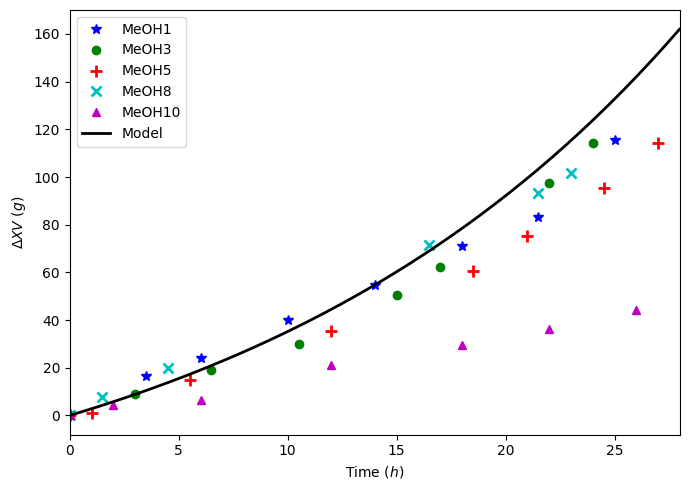

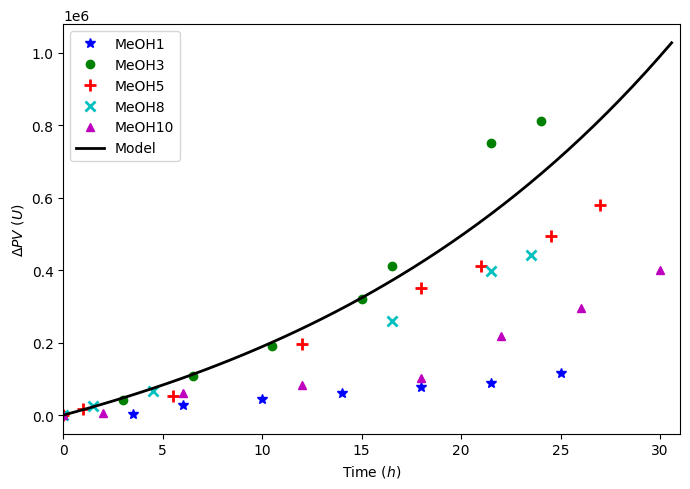

In [27]:
# ============================================================
# Límites temporales de los datos experimentales
# ============================================================

tmax_A = np.nanmax([
    np.nanmax(tm01),
    np.nanmax(tm3),
    np.nanmax(tm5),
    np.nanmax(tm8),
    np.nanmax(tm10)
])

tmax_A = tmax_A+1

tmax_B = np.nanmax([
    np.nanmax(Ptm01),
    np.nanmax(Ptm3),
    np.nanmax(Ptm5),
    np.nanmax(Ptm8),
    np.nanmax(Ptm10)
])

tmax_B = tmax_B+1


# ============================================================
# Filtrar solución del modelo al intervalo experimental
# ============================================================

mask_A = Predtime <= tmax_A

time_model_A = Predtime[mask_A]
biomass_model_A = PRED[mask_A]


mask_B = Predtime_P <= tmax_B

time_model_B = Predtime_P[mask_B]
protein_model_B = Pred_P[mask_B]


# ============================================================
# FIGURA 4A
# Incremento de biomasa total
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(tm01, M1, 'b*', markersize=7, label='MeOH1')
plt.plot(tm3, M3, 'go', markersize=6, label='MeOH3')
plt.plot(tm5, M5, 'r+', markersize=8, markeredgewidth=2, label='MeOH5')
plt.plot(tm8, M8, 'cx', markersize=7, markeredgewidth=2, label='MeOH8')
plt.plot(tm10, M10, 'm^', markersize=6, label='MeOH10')

# Modelo solamente hasta el máximo tiempo experimental
plt.plot(
    time_model_A,
    biomass_model_A,
    'k',
    linewidth=2,
    label='Model'
)

plt.xlabel('Time ($h$)')
plt.ylabel(r'$\Delta XV$ ($g$)')

plt.xlim(0, tmax_A)

plt.legend(loc='best')
plt.tight_layout()

plt.savefig(
    'Fig4A.png',
    format='png',
    dpi=300
)

plt.show()


# ============================================================
# FIGURA 4B
# Incremento de proteína total
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(Ptm01, PM1, 'b*', markersize=7, label='MeOH1')
plt.plot(Ptm3, PM3, 'go', markersize=6, label='MeOH3')
plt.plot(Ptm5, PM5, 'r+', markersize=8, markeredgewidth=2, label='MeOH5')
plt.plot(Ptm8, PM8, 'cx', markersize=7, markeredgewidth=2, label='MeOH8')
plt.plot(Ptm10, PM10, 'm^', markersize=6, label='MeOH10')

# Modelo solamente hasta el máximo tiempo experimental
plt.plot(
    time_model_B,
    protein_model_B,
    'k',
    linewidth=2,
    label='Model'
)

plt.xlabel('Time ($h$)')
plt.ylabel(r'$\Delta PV$ ($U$)')

plt.xlim(0, tmax_B)

plt.legend(loc='best')
plt.tight_layout()

plt.savefig(
    'Fig4B.png',
    format='png',
    dpi=300
)

plt.show()

Grafico Doble: Proteina y velocidad de crecimiento

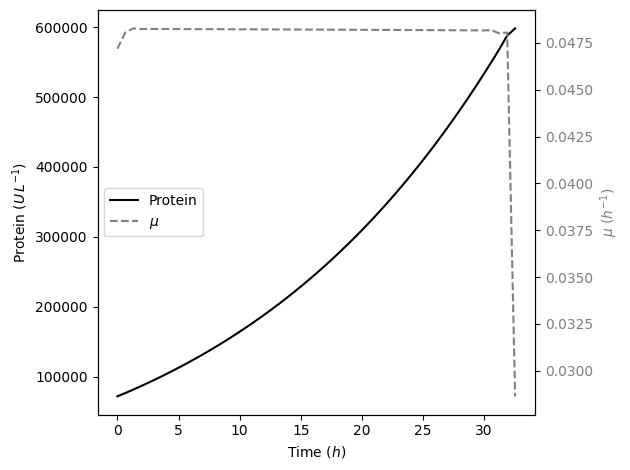

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Los datos ya están contenidos en "tabla"
# ============================================================

t = tabla['Time'].values
r = tabla['Protein_density'].values
s = tabla['Substrate'].values

# ============================================================
# Cálculo de la tasa específica de crecimiento mu
# ============================================================

MuM = 0.069
KM = 0.4
KI = 8.85

Mu = MuM * s / (KM + s + s**2 / KI)

# Opcional: incorporar mu a la tabla
tabla['mu'] = Mu

# ============================================================
# Gráfico: proteína y tasa específica de crecimiento
# ============================================================

fig, ax1 = plt.subplots()

# ============================================================
# Eje izquierdo: Protein
# ============================================================

color = 'k'

ax1.set_xlabel('Time ($h$)')
ax1.set_ylabel(r'Protein ($U\,L^{-1}$)', color=color)

ax1.plot(
    t,
    r,
    color=color,
    label='Protein'
)

ax1.tick_params(axis='y', labelcolor=color)

# ============================================================
# Eje derecho: mu
# ============================================================

ax2 = ax1.twinx()

color = 'tab:gray'

ax2.set_ylabel(r'$\mu$ ($h^{-1}$)', color=color)

ax2.plot(
    t,
    Mu,
    '--',
    color=color,
    label=r'$\mu$'
)

ax2.tick_params(axis='y', labelcolor=color)

# ============================================================
# Leyenda combinada
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center left',
    frameon=True
)

# ============================================================
# Ajuste y guardado
# ============================================================

fig.tight_layout()

plt.savefig(
    'FigMu.eps',
    format='eps'
)

plt.show()